# Nhận Dạng Lệnh Thoại với SVM + MFCC
**Ứng dụng Machine Learning trong điều khiển đối tượng trên Web bằng lệnh thoại thời gian thực**

Pipeline:
1. Đọc dữ liệu từ dataset (down / left / right / up)
2. Trích xuất đặc trưng MFCC (song song, có cache)
3. Huấn luyện SVM + Grid Search (verbose)
4. Đánh giá mô hình
5. Lưu mô hình để deploy Flask

## 0. Cài đặt thư viện (chạy 1 lần)

In [1]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "librosa", "scikit-learn", "joblib", "numpy",
    "matplotlib", "seaborn", "tqdm", "soundfile", "pandas"
], check=True)
print("\nCài đặt xong!")


Cài đặt xong!


## 1. Import thư viện

In [7]:
import os
import time
import warnings
import subprocess
import sys

# Tắt cảnh báo không cần thiết
warnings.filterwarnings('ignore')

import numpy as np
import librosa
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from joblib import Parallel, delayed
from tqdm import tqdm  # Dùng tqdm thay cho tqdm.notebook trên VS Code

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

## 2. Cấu hình đường dẫn Dataset

In [8]:
#  CHỈNH SỬA ĐƯỜNG DẪN NÀY CHO ĐÚNG MÁY CỦA BẠN
DATASET_DIR     = r"Dataset_Audio"
TESTING_LIST    = os.path.join(DATASET_DIR, "testing_list.txt")
VALIDATION_LIST = os.path.join(DATASET_DIR, "validation_list.txt")

CLASSES      = ["down", "left", "right", "up"]
SAMPLE_RATE  = 16000     # Tần số lấy mẫu âm thanh
DURATION     = 1.0       # Độ dài mỗi file âm thanh
N_MFCC       = 40        # Số hệ số MFCC trích xuất
N_JOBS       = -1        # -1 = dùng toàn bộ CPU core

MODEL_PATH   = "svm_speech_model.joblib"
SCALER_PATH  = "scaler.joblib"
ENCODER_PATH = "label_encoder.joblib"
CACHE_DIR    = "mfcc_cache"   # cache numpy để lần sau load lại rất nhanh

os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Dataset : {DATASET_DIR}")
print(f"Classes : {CLASSES}")
print(f"Cache   : {CACHE_DIR}/")

Dataset : Dataset_Audio
Classes : ['down', 'left', 'right', 'up']
Cache   : mfcc_cache/


## 3. Hàm trích xuất MFCC (song song + cache)

In [4]:
def extract_mfcc(file_path, sr=SAMPLE_RATE, duration=DURATION, n_mfcc=N_MFCC):
    """Đọc 1 file WAV → vector MFCC (mean + std), shape = (n_mfcc*2,)"""
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        target = int(sr * duration)
        y = np.pad(y, (0, max(0, target - len(y))))[:target]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])
    except Exception:
        return None


def _load_one(full_path, label):
    feat = extract_mfcc(full_path)
    return (feat, label) if feat is not None else None


def parallel_load(tasks, desc="Đọc file"):
    """tasks = list of (full_path, label). Trả về (X, y) numpy arrays."""
    results = Parallel(n_jobs=N_JOBS, prefer="threads")(
        delayed(_load_one)(fp, lbl)
        for fp, lbl in tqdm(tasks, desc=f"  {desc}", unit="file")
    )
    results = [r for r in results if r is not None]
    return np.array([r[0] for r in results]), np.array([r[1] for r in results])


def load_split_from_list(list_file, dataset_dir, classes, desc=""):
    with open(list_file, 'r') as f:
        lines = [l.strip() for l in f if l.split('/')[0] in classes]
    tasks = [(os.path.join(dataset_dir, p), p.split('/')[0]) for p in lines]
    return parallel_load(tasks, desc=desc)


def load_train_split(dataset_dir, classes, excluded):
    tasks = []
    for label in classes:
        folder = os.path.join(dataset_dir, label)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.endswith('.wav'):
                continue
            rel = f"{label}/{fname}"
            if rel not in excluded:
                tasks.append((os.path.join(dataset_dir, rel), label))
    return parallel_load(tasks, desc="TRAIN")


def cached_load(cache_name, loader_fn):
    """Dùng cache .npy nếu đã có, không thì load thật rồi lưu cache."""
    cx = os.path.join(CACHE_DIR, f"{cache_name}_X.npy")
    cy = os.path.join(CACHE_DIR, f"{cache_name}_y.npy")
    if os.path.exists(cx) and os.path.exists(cy):
        print(f"Dùng cache sẵn có: {cache_name}")
        return np.load(cx), np.load(cy, allow_pickle=True)
    X, y = loader_fn()
    np.save(cx, X)
    np.save(cy, y)
    print(f"Đã lưu cache: {cache_name}")
    return X, y


print("Định nghĩa hàm xong!")

Định nghĩa hàm xong!


## 4. Tải dữ liệu
> Lần đầu mất ~2–3 phút, lần sau load cache chỉ tốn vài giây.

In [9]:
with open(TESTING_LIST, 'r') as f:
    test_files = set(l.strip() for l in f)
with open(VALIDATION_LIST, 'r') as f:
    val_files = set(l.strip() for l in f)

print(f"File test : {len(test_files):,}")
print(f"File val  : {len(val_files):,}")

t0 = time.time()
print("\nTải TRAIN ...")
X_train, y_train = cached_load(
    "train",
    lambda: load_train_split(DATASET_DIR, CLASSES, test_files | val_files)
)
print(f"{len(X_train):,} mẫu | {time.time()-t0:.1f}s")

t0 = time.time()
print("\nTải VALIDATION ...")
X_val, y_val = cached_load(
    "val",
    lambda: load_split_from_list(VALIDATION_LIST, DATASET_DIR, CLASSES, "VALIDATION")
)
print(f"{len(X_val):,} mẫu | {time.time()-t0:.1f}s")

t0 = time.time()
print("\nTải TEST ...")
X_test, y_test = cached_load(
    "test",
    lambda: load_split_from_list(TESTING_LIST, DATASET_DIR, CLASSES, "TEST")
)
print(f"{len(X_test):,} mẫu | {time.time()-t0:.1f}s")

print(f"\nChiều đặc trưng: {X_train.shape[1]} (= {N_MFCC} MFCC × 2 thống kê)")

File test : 1,639
File val  : 1,442

Tải TRAIN ...
Dùng cache sẵn có: train
12,138 mẫu | 0.0s

Tải VALIDATION ...
Dùng cache sẵn có: val
1,442 mẫu | 0.0s

Tải TEST ...
Dùng cache sẵn có: test
1,639 mẫu | 0.0s

Chiều đặc trưng: 80 (= 40 MFCC × 2 thống kê)


## 5. Tiền xử lý: chuẩn hóa & mã hóa nhãn

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

le = LabelEncoder()
le.fit(CLASSES)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Mapping nhãn:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nPhân bố tập train:")
for cls in CLASSES:
    print(f"- {cls:6s}: {np.sum(y_train == cls):,} mẫu")

Mapping nhãn: {np.str_('down'): np.int64(0), np.str_('left'): np.int64(1), np.str_('right'): np.int64(2), np.str_('up'): np.int64(3)}

Phân bố tập train:
- down  : 3,134 mẫu
- left  : 3,037 mẫu
- right : 3,019 mẫu
- up    : 2,948 mẫu


## 6. Trực quan hóa MFCC

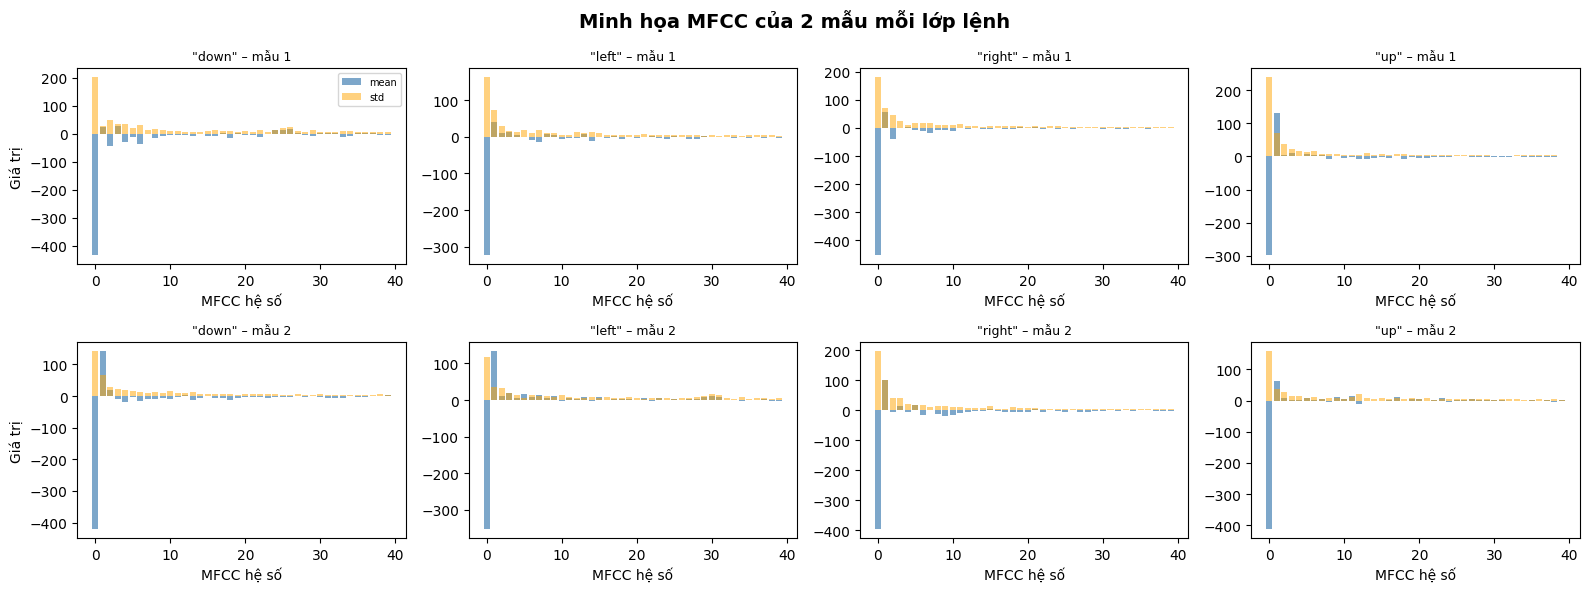

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("Minh họa MFCC của 2 mẫu mỗi lớp lệnh", fontsize=14, fontweight='bold')

for col_idx, cls in enumerate(CLASSES):
    indices = np.where(y_train == cls)[0][:2]
    for row_idx, idx in enumerate(indices):
        ax = axes[row_idx][col_idx]
        feat = X_train[idx].reshape(2, N_MFCC)
        ax.bar(range(N_MFCC), feat[0], alpha=0.7, label='mean', color='steelblue')
        ax.bar(range(N_MFCC), feat[1], alpha=0.5, label='std',  color='orange')
        ax.set_title(f'"{cls}" – mẫu {row_idx+1}', fontsize=9)
        ax.set_xlabel('MFCC hệ số')
        if col_idx == 0:
            ax.set_ylabel('Giá trị')
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
save_path = '/content/drive/MyDrive/AI/project/results'
os.makedirs(save_path, exist_ok=True)

plt.savefig(f'{save_path}/mfcc_visualization.png', dpi=120, bbox_inches='tight')

## 7. Huấn luyện SVM – Grid Search
> `verbose=2` sẽ in ra từng lần fit để bạn theo dõi tiến trình.

In [11]:
X_trainval = np.vstack([X_train_sc, X_val_sc])
y_trainval  = np.concatenate([y_train_enc, y_val_enc])

param_grid = {
    'C':      [0.1, 1, 10, 100, 1000],
    'gamma':  ['scale', 0.001, 0.01, 0.1, 1],
    # 'C':      [0.1, 1, 10, 100],
    # 'gamma':  ['scale', 0.1, 1],
    'kernel': ['rbf']
}

CV_FOLDS   = 5
n_combos   = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])
total_fits = n_combos * CV_FOLDS

print(f"Tổ hợp tham số  : {n_combos}")
print(f"CV folds         : {CV_FOLDS}")
print(f"Tổng số lần fit  : {total_fits}")
print(f"CPU cores dùng   : tất cả (n_jobs=-1)")
print("─" * 50)

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=CV_FOLDS,
    scoring='accuracy',
    n_jobs=N_JOBS,
    verbose=2,      # in từng lần fit
    refit=True
)

print("Bắt đầu Grid Search ...\n")
t0 = time.time()
grid.fit(X_trainval, y_trainval)
elapsed = time.time() - t0

print(f"\n{'='*50}")
print(f"Grid Search xong! ({elapsed:.1f}s)")
print(f"Tham số tốt nhất : {grid.best_params_}")
print(f"CV accuracy      : {grid.best_score_*100:.2f}%")
print(f"{'='*50}")

best_svm = grid.best_estimator_

Tổ hợp tham số  : 25
CV folds         : 5
Tổng số lần fit  : 125
CPU cores dùng   : tất cả (n_jobs=-1)
──────────────────────────────────────────────────
Bắt đầu Grid Search ...

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Grid Search xong! (3593.9s)
Tham số tốt nhất : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy      : 76.63%


## 8. Bảng so sánh các tổ hợp tham số

In [12]:
cv_df = pd.DataFrame(grid.cv_results_)[[
    'param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

cv_df['mean_test_score'] = (cv_df['mean_test_score'] * 100).round(2)
cv_df['std_test_score']  = (cv_df['std_test_score']  * 100).round(2)
cv_df.columns = ['C', 'gamma', 'CV Acc (%)', 'Std (%)', 'Rank']
print(cv_df.to_string(index=False))

     C  gamma  CV Acc (%)  Std (%)  Rank
   1.0  scale       76.63     0.94     1
   1.0   0.01       76.55     0.79     2
 100.0  0.001       76.06     0.54     3
  10.0  scale       75.88     0.99     4
  10.0   0.01       75.82     0.95     5
1000.0  scale       75.58     1.02     6
 100.0  scale       75.58     1.02     6
1000.0   0.01       75.18     0.96     8
 100.0   0.01       75.18     0.96     8
  10.0  0.001       74.66     1.23    10
1000.0  0.001       73.35     0.84    11
   1.0  0.001       72.53     1.01    12
   0.1   0.01       71.88     1.22    13
   0.1  scale       71.21     1.45    14
   0.1  0.001       67.09     1.29    15
1000.0    0.1       57.46     1.73    16
 100.0    0.1       57.46     1.73    16
  10.0    0.1       57.46     1.73    16
   1.0    0.1       56.07     1.42    19
  10.0      1       26.22     0.18    20
   1.0      1       26.22     0.18    20
 100.0      1       26.22     0.18    20
1000.0      1       26.22     0.18    20
   0.1    0.1   

## 9. Đánh giá mô hình

In [13]:
y_val_pred  = best_svm.predict(X_val_sc)
y_test_pred = best_svm.predict(X_test_sc)

val_acc  = accuracy_score(y_val_enc,  y_val_pred)
test_acc = accuracy_score(y_test_enc, y_test_pred)

print(f"{'='*50}")
print(f"  Validation Accuracy : {val_acc*100:.2f}%")
print(f"  Test       Accuracy : {test_acc*100:.2f}%")
print(f"{'='*50}")

print("\n── Validation Report ──")
print(classification_report(y_val_enc, y_val_pred, target_names=le.classes_))

print("── Test Report ──")
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

  Validation Accuracy : 90.08%
  Test       Accuracy : 75.72%

── Validation Report ──
              precision    recall  f1-score   support

        down       0.88      0.89      0.88       377
        left       0.87      0.93      0.90       352
       right       0.95      0.87      0.91       363
          up       0.91      0.91      0.91       350

    accuracy                           0.90      1442
   macro avg       0.90      0.90      0.90      1442
weighted avg       0.90      0.90      0.90      1442

── Test Report ──
              precision    recall  f1-score   support

        down       0.72      0.74      0.73       406
        left       0.74      0.75      0.74       412
       right       0.75      0.74      0.74       396
          up       0.82      0.80      0.81       425

    accuracy                           0.76      1639
   macro avg       0.76      0.76      0.76      1639
weighted avg       0.76      0.76      0.76      1639



## 10. Confusion Matrix

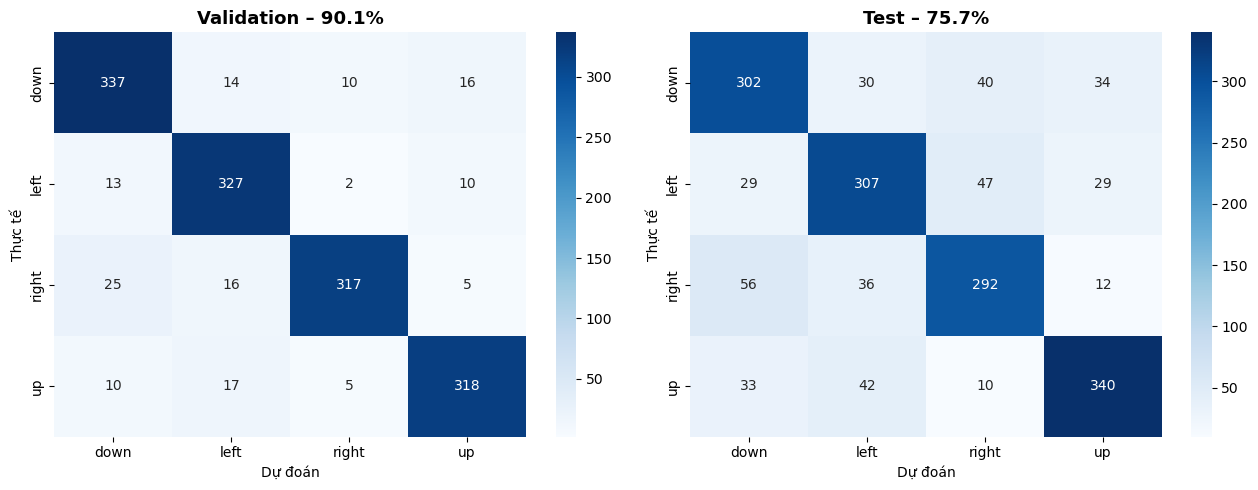

✅ Đã lưu confusion_matrix.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val_enc,  y_val_pred,  f'Validation – {val_acc*100:.1f}%'),
    (axes[1], y_test_enc, y_test_pred, f'Test – {test_acc*100:.1f}%'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Đã lưu confusion_matrix.png")

## 11. Phân tích độ trễ xử lý

⏱️  Trung bình : 299.8 ms
⏱️  Min / Max  : 4.3 / 14757.7 ms


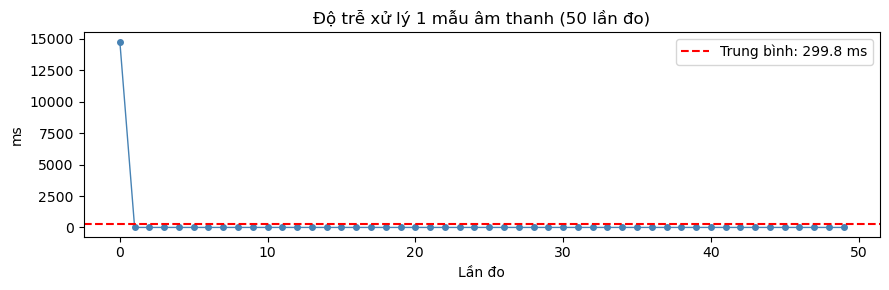

In [15]:
sample_file = os.path.join(
    DATASET_DIR, "down",
    os.listdir(os.path.join(DATASET_DIR, "down"))[0]
)

latencies = []
for _ in range(50):
    t0 = time.perf_counter()
    feat   = extract_mfcc(sample_file)
    feat_s = scaler.transform([feat])
    best_svm.predict(feat_s)
    latencies.append((time.perf_counter() - t0) * 1000)

print(f"⏱️  Trung bình : {np.mean(latencies):.1f} ms")
print(f"⏱️  Min / Max  : {np.min(latencies):.1f} / {np.max(latencies):.1f} ms")

plt.figure(figsize=(9, 3))
plt.plot(latencies, marker='o', ms=4, color='steelblue', linewidth=1)
plt.axhline(np.mean(latencies), color='red', linestyle='--',
            label=f'Trung bình: {np.mean(latencies):.1f} ms')
plt.title('Độ trễ xử lý 1 mẫu âm thanh (50 lần đo)')
plt.xlabel('Lần đo'); plt.ylabel('ms')
plt.legend(); plt.tight_layout()
plt.savefig('latency.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Lưu mô hình

In [17]:
joblib.dump(best_svm, MODEL_PATH)
joblib.dump(scaler,   SCALER_PATH)
joblib.dump(le,       ENCODER_PATH)

print(f"💾 Model   → {MODEL_PATH}")
print(f"💾 Scaler  → {SCALER_PATH}")
print(f"💾 Encoder → {ENCODER_PATH}")
print("\n🚀 Sẵn sàng deploy Flask!")

💾 Model   → svm_speech_model.joblib
💾 Scaler  → scaler.joblib
💾 Encoder → label_encoder.joblib

🚀 Sẵn sàng deploy Flask!


## 13. Kiểm tra nhanh dự đoán

In [16]:
def predict_audio(file_path):
    feat   = extract_mfcc(file_path)
    feat_s = scaler.transform([feat])
    pred   = best_svm.predict(feat_s)[0]
    proba  = best_svm.predict_proba(feat_s)[0]
    label  = le.inverse_transform([pred])[0]
    conf   = proba[pred] * 100
    return label, conf

print("Thử dự đoán 1 file từ mỗi lớp:\n")
for cls in CLASSES:
    folder     = os.path.join(DATASET_DIR, cls)
    first_file = os.path.join(folder, os.listdir(folder)[0])
    result, conf = predict_audio(first_file)
    status = '✅' if result == cls else '❌'
    print(f"  {status}  Thật: {cls:6s} | Dự đoán: {result:6s} | Tin cậy: {conf:.1f}%")

Thử dự đoán 1 file từ mỗi lớp:

  ✅  Thật: down   | Dự đoán: down   | Tin cậy: 96.2%
  ✅  Thật: left   | Dự đoán: left   | Tin cậy: 99.0%
  ✅  Thật: right  | Dự đoán: right  | Tin cậy: 79.4%
  ✅  Thật: up     | Dự đoán: up     | Tin cậy: 69.5%
